In [1]:
#!rm /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/cka_results.json

In [2]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)


# Download results data from HuggingFace (too large for git)
from huggingface_hub import hf_hub_download
RESULTS_DIR = os.path.join(EXP_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
for fname in ["classifications.json", "cot_texts.json"]:
    target = os.path.join(RESULTS_DIR, fname)
    if not os.path.exists(target):
        print(f"Downloading {fname} from HuggingFace...")
        hf_hub_download(
            repo_id="Noddybear/legibility-data",
            filename=f"results/{fname}",
            repo_type="dataset",
            local_dir=EXP_DIR,
        )
    else:
        print(f"CACHED: {fname}")

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 740a19f Update Phase 2 code for larger dataset and add NB10 perplexity analysis


# NB4: CKA Representational Geometry (Experiment A2)

**CPU notebook** (~30 min). Compares representational geometry between legible and
illegible CoTs using Centered Kernel Alignment (CKA).

At each layer, compute linear CKA between legible and illegible activation trajectories
(resampled to fixed relative positions). Aggregate with bootstrap CIs.
Split by foreignness to check distributional-shift confound.

**Requires:** NB1 outputs (`activations/{G1,G3}_full_seq/`)

In [ ]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_activations, load_distributional_shift_scores, linear_cka,
    resample_to_relative_positions, bootstrap_ci_metric,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Checkpoint: check if final output already exists (including R5 CKA keys)
_output_path = PHASE2_RESULTS_DIR / 'cka_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    _has_r5 = 'R5_legibility_cka' in _saved and 'R5_c2_success_cka' in _saved
    print(f"CACHED: {_output_path} exists.")
    for model_name in _saved:
        n_layers = len(_saved[model_name])
        print(f"  {model_name}: {n_layers} layers computed")
    if not _has_r5:
        print("NOTE: R5 CKA keys not yet computed -- will re-run.")
    else:
        print("Delete this file and re-run to recompute.")

In [5]:
# Load full-sequence activations
g3_full = load_activations(ACTIVATIONS_DIR / "G3_full_seq")
g1_full = load_activations(ACTIVATIONS_DIR / "G1_full_seq")

# Load metadata
with open(ACTIVATIONS_DIR / "G3_full_seq" / "metadata.json") as f:
    g3_meta = json.load(f)
with open(ACTIVATIONS_DIR / "G1_full_seq" / "metadata.json") as f:
    g1_meta = json.load(f)

g3_labels = [s[3] for s in g3_meta['sample_ids']]
g1_labels = [s[3] for s in g1_meta['sample_ids']]

print(f"G3 full-seq: {len(g3_labels)} samples, layers={sorted(g3_full.keys())}")
print(f"G1 full-seq: {len(g1_labels)} samples, layers={sorted(g1_full.keys())}")
print(f"G3 labels: {dict(Counter(g3_labels))}")
print(f"G1 labels: {dict(Counter(g1_labels))}")

G3 full-seq: 156 samples, layers=[0, 8, 16, 24, 32, 40, 48, 63]
G1 full-seq: 164 samples, layers=[0, 8, 16, 24, 32, 40, 48, 63]
G3 labels: {'ILLEGIBLE': 126, 'REASONING_LEGIBLE': 30}
G1 labels: {'ILLEGIBLE': 131, 'REASONING_LEGIBLE': 33}


In [6]:
# For each layer, resample sequences to fixed positions and compute CKA
# between legible vs illegible groups.
N_POSITIONS = 20  # Fixed number of relative positions

def linear_cka_fast(X, Y):
    """Linear CKA using the dual (Gram) formulation -- O(n^2) not O(d^2).
    
    When n_samples << n_features, computing n x n Gram matrices is much
    faster than d x d covariance matrices.
    """
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    
    # Gram matrices (n x n)
    GX = X @ X.T
    GY = Y @ Y.T
    
    hsic_xy = np.sum(GX * GY)  # trace(GX @ GY) via element-wise
    hsic_xx = np.sum(GX * GX)
    hsic_yy = np.sum(GY * GY)
    
    denom = np.sqrt(hsic_xx * hsic_yy)
    return float(hsic_xy / denom) if denom > 0 else 0.0

def compute_group_cka(full_acts, labels, layer_indices, n_positions=N_POSITIONS):
    """Compute CKA between legible and illegible groups at each layer."""
    legible_idx = [i for i, l in enumerate(labels) if l == 'REASONING_LEGIBLE']
    illegible_idx = [i for i, l in enumerate(labels) if l == 'ILLEGIBLE']
    
    print(f"Legible: {len(legible_idx)}, Illegible: {len(illegible_idx)}")
    
    if len(legible_idx) < 3 or len(illegible_idx) < 3:
        print("Insufficient samples for CKA")
        return {}
    
    n_match = min(len(legible_idx), len(illegible_idx))
    
    results = {}
    for layer_idx in sorted(layer_indices):
        import time
        t0 = time.time()
        acts_list = full_acts[layer_idx]
        
        # Resample each sequence to fixed positions
        legible_resampled = []
        for i in legible_idx[:n_match]:
            resampled = resample_to_relative_positions(acts_list[i], n_positions)
            legible_resampled.append(resampled.flatten())
        
        illegible_resampled = []
        for i in illegible_idx[:n_match]:
            resampled = resample_to_relative_positions(acts_list[i], n_positions)
            illegible_resampled.append(resampled.flatten())
        
        X_leg = np.array(legible_resampled)
        X_ill = np.array(illegible_resampled)
        
        # CKA between groups
        cka_val = linear_cka_fast(X_leg, X_ill)
        
        # Within-group CKA as baseline (self-similarity)
        if len(legible_idx) >= 6:
            half = n_match // 2
            cka_self_leg = linear_cka_fast(X_leg[:half], X_leg[half:2*half])
        else:
            cka_self_leg = np.nan
        
        # Bootstrap CI on CKA -- resample PAIRED indices to preserve
        # group structure. Each bootstrap draws the same indices for
        # both legible and illegible, so the CI reflects estimation
        # uncertainty rather than random permutation variance.
        boot_ckas = []
        rng = np.random.RandomState(42)
        for _ in range(1000):
            idx = rng.choice(n_match, size=n_match, replace=True)
            boot_cka = linear_cka_fast(X_leg[idx], X_ill[idx])
            boot_ckas.append(boot_cka)
        boot_ckas = np.array(boot_ckas)
        ci_lo = float(np.percentile(boot_ckas, 2.5))
        ci_hi = float(np.percentile(boot_ckas, 97.5))
        
        results[layer_idx] = {
            'cka': float(cka_val),
            'cka_ci': (ci_lo, ci_hi),
            'cka_self_legible': float(cka_self_leg),
            'n_legible': n_match,
            'n_illegible': n_match,
        }
        elapsed = time.time() - t0
        print(f"  Layer {layer_idx}: CKA={cka_val:.3f} [{ci_lo:.3f}, {ci_hi:.3f}] "
              f"self_leg={cka_self_leg:.3f} ({elapsed:.1f}s)")
    
    return results

print("=== G3 CKA ===")
g3_cka = compute_group_cka(g3_full, g3_labels, sorted(g3_full.keys()))

print("\n=== G1 CKA ===")
g1_cka = compute_group_cka(g1_full, g1_labels, sorted(g1_full.keys()))

=== G3 CKA ===
Legible: 30, Illegible: 126
  Layer 0: CKA=0.928 [0.943, 0.972] self_leg=0.932 (72.4s)
  Layer 8: CKA=0.041 [0.030, 0.286] self_leg=0.132 (28.7s)
  Layer 16: CKA=0.082 [0.092, 0.351] self_leg=0.286 (28.5s)
  Layer 24: CKA=0.126 [0.151, 0.433] self_leg=0.364 (39.5s)
  Layer 32: CKA=0.189 [0.226, 0.535] self_leg=0.448 (30.5s)
  Layer 40: CKA=0.188 [0.225, 0.533] self_leg=0.456 (37.5s)
  Layer 48: CKA=0.389 [0.437, 0.742] self_leg=0.641 (41.0s)
  Layer 63: CKA=0.908 [0.925, 0.963] self_leg=0.945 (28.9s)

=== G1 CKA ===
Legible: 33, Illegible: 131
  Layer 0: CKA=0.902 [0.926, 0.962] self_leg=0.954 (30.2s)
  Layer 8: CKA=0.084 [0.004, 0.334] self_leg=0.009 (30.5s)
  Layer 16: CKA=0.086 [0.009, 0.338] self_leg=0.013 (30.2s)
  Layer 24: CKA=0.087 [0.014, 0.342] self_leg=0.016 (30.0s)
  Layer 32: CKA=0.087 [0.018, 0.346] self_leg=0.020 (30.0s)
  Layer 40: CKA=0.088 [0.022, 0.349] self_leg=0.022 (30.1s)
  Layer 48: CKA=0.092 [0.050, 0.369] self_leg=0.042 (29.1s)
  Layer 63: CKA=0

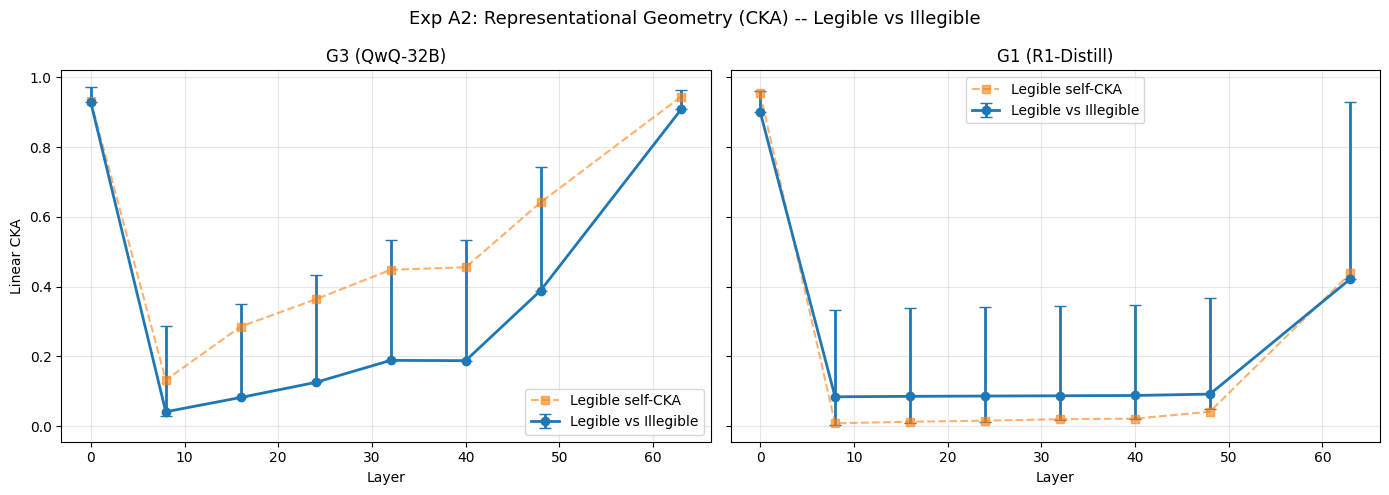

In [7]:
# Plot CKA across layers
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, name, cka_results in [(axes[0], 'G3 (QwQ-32B)', g3_cka),
                               (axes[1], 'G1 (R1-Distill)', g1_cka)]:
    if not cka_results:
        ax.set_title(f'{name}: insufficient data')
        continue
    
    layers = sorted(cka_results.keys())
    cka_vals = [cka_results[l]['cka'] for l in layers]
    ci_los = [cka_results[l]['cka_ci'][0] for l in layers]
    ci_his = [cka_results[l]['cka_ci'][1] for l in layers]
    self_vals = [cka_results[l]['cka_self_legible'] for l in layers]
    
    yerr_lo = [max(0, v - lo) for v, lo in zip(cka_vals, ci_los)]
    yerr_hi = [max(0, hi - v) for v, hi in zip(cka_vals, ci_his)]
    
    ax.errorbar(layers, cka_vals, yerr=[yerr_lo, yerr_hi],
                fmt='o-', capsize=4, label='Legible vs Illegible', linewidth=2)
    ax.plot(layers, self_vals, 's--', alpha=0.6, label='Legible self-CKA', linewidth=1.5)
    ax.set_xlabel('Layer')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Linear CKA')
fig.suptitle('Exp A2: Representational Geometry (CKA) -- Legible vs Illegible', fontsize=13)
fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'a2_cka_geometry.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# R2 perplexity covariate check: compare legible vs illegible
ds_scores = load_distributional_shift_scores()

# Get R2 perplexity per G3 sample
g3_sample_perplexity = []
for s in g3_meta['sample_ids']:
    sid, gid, epoch, label = s
    key = (sid, gid, epoch, 'R2')
    entry = ds_scores.get(key)
    g3_sample_perplexity.append(entry['reader_perplexity'] if entry else np.nan)

g3_sample_perplexity = np.array(g3_sample_perplexity)
valid = np.isfinite(g3_sample_perplexity)

print(f"R2 perplexity available for {valid.sum()}/{len(g3_sample_perplexity)} samples")

if valid.sum() > 0:
    # Report perplexity by label
    for label in ['REASONING_LEGIBLE', 'ILLEGIBLE']:
        mask = [l == label and v for l, v in zip(g3_labels, valid)]
        if any(mask):
            p_vals = g3_sample_perplexity[mask]
            print(f"  {label}: mean_perplexity={p_vals.mean():.2f} +/- {p_vals.std():.2f} (n={len(p_vals)})")

    # t-test between groups
    leg_p = g3_sample_perplexity[[l == 'REASONING_LEGIBLE' and v for l, v in zip(g3_labels, valid)]]
    ill_p = g3_sample_perplexity[[l == 'ILLEGIBLE' and v for l, v in zip(g3_labels, valid)]]
    if len(leg_p) > 1 and len(ill_p) > 1:
        from scipy import stats
        t_stat, p_val = stats.ttest_ind(leg_p, ill_p)
        print(f"  t-test (legible vs illegible): t={t_stat:.2f}, p={p_val:.4f}")
else:
    print("No R2 perplexity data available for CKA split")

## Reader-Side CKA: R5 Activation Geometry

Instead of comparing legible vs illegible full-sequence generator activations (which are
resampled to fixed relative positions, yielding 20*5120 = 102400 dim vectors), here we
use R5 **last-token** activations (5376 dim per sample). This is a complementary analysis:
generator CKA measures whether reasoning *trajectories* differ geometrically, while reader
CKA measures whether the reader's *final representation* differs for legible vs illegible CoTs.

We compute CKA between:
1. Legible vs illegible groups (by generator legibility label)
2. C2 success vs failure groups (reader crossfill outcome)

In [ ]:
# Load R5 last-token activations and metadata
from phase2_utils import load_activations, train_binary_probe
import time

r5_last = load_activations(ACTIVATIONS_DIR / "R5_last_token")
with open(ACTIVATIONS_DIR / "R5_last_token" / "metadata.json") as f:
    r5_meta = json.load(f)

r5_c2_labels = np.array(r5_meta['labels'])  # 1=C2 success, 0=C2 failure
r5_sample_meta = r5_meta['sample_metadata']

# Build legibility mask (excl. ANSWER_LEAKED)
r5_leg_labels = np.array([m['label'] for m in r5_sample_meta])
r5_legible_mask = r5_leg_labels == 'REASONING_LEGIBLE'
r5_illegible_mask = r5_leg_labels == 'ILLEGIBLE'
r5_non_leaked_mask = r5_legible_mask | r5_illegible_mask

n_legible = r5_legible_mask.sum()
n_illegible = r5_illegible_mask.sum()
print(f"R5 activations: {len(r5_c2_labels)} samples, layers={sorted(r5_last.keys())}")
print(f"Legible: {n_legible}, Illegible: {n_illegible}")

# Subsample larger group to match
n_match = min(n_legible, n_illegible)
rng = np.random.RandomState(42)
legible_idx = np.where(r5_legible_mask)[0]
illegible_idx = np.where(r5_illegible_mask)[0]

if n_legible > n_match:
    legible_idx = rng.choice(legible_idx, size=n_match, replace=False)
else:
    illegible_idx = rng.choice(illegible_idx, size=n_match, replace=False)

print(f"Matched groups: n={n_match} each")

# Compute CKA between legible vs illegible at each layer
r5_legibility_cka = {}
for layer_idx in sorted(r5_last.keys()):
    t0 = time.time()
    X_leg = r5_last[layer_idx][legible_idx]
    X_ill = r5_last[layer_idx][illegible_idx]

    cka_val = linear_cka_fast(X_leg, X_ill)

    # Bootstrap CI (1000 iterations)
    boot_ckas = []
    for _ in range(1000):
        idx = rng.choice(n_match, size=n_match, replace=True)
        boot_cka = linear_cka_fast(X_leg[idx], X_ill[idx])
        boot_ckas.append(boot_cka)
    boot_ckas = np.array(boot_ckas)
    ci_lo = float(np.percentile(boot_ckas, 2.5))
    ci_hi = float(np.percentile(boot_ckas, 97.5))

    r5_legibility_cka[layer_idx] = {
        'cka': float(cka_val),
        'cka_ci': (ci_lo, ci_hi),
        'n_legible': int(n_match),
        'n_illegible': int(n_match),
    }
    elapsed = time.time() - t0
    print(f"  Layer {layer_idx}: CKA={cka_val:.3f} [{ci_lo:.3f}, {ci_hi:.3f}] ({elapsed:.1f}s)")

# C2 success vs failure CKA (excluding leaked)
non_leaked_success = np.where(r5_non_leaked_mask & (r5_c2_labels == 1))[0]
non_leaked_failure = np.where(r5_non_leaked_mask & (r5_c2_labels == 0))[0]
n_match_c2 = min(len(non_leaked_success), len(non_leaked_failure))

print(f"\nC2 success: {len(non_leaked_success)}, failure: {len(non_leaked_failure)}, matched: {n_match_c2}")

if len(non_leaked_success) > n_match_c2:
    non_leaked_success = rng.choice(non_leaked_success, size=n_match_c2, replace=False)
else:
    non_leaked_failure = rng.choice(non_leaked_failure, size=n_match_c2, replace=False)

r5_c2_success_cka = {}
for layer_idx in sorted(r5_last.keys()):
    t0 = time.time()
    X_suc = r5_last[layer_idx][non_leaked_success]
    X_fail = r5_last[layer_idx][non_leaked_failure]

    cka_val = linear_cka_fast(X_suc, X_fail)

    boot_ckas = []
    for _ in range(1000):
        idx = rng.choice(n_match_c2, size=n_match_c2, replace=True)
        boot_cka = linear_cka_fast(X_suc[idx], X_fail[idx])
        boot_ckas.append(boot_cka)
    boot_ckas = np.array(boot_ckas)
    ci_lo = float(np.percentile(boot_ckas, 2.5))
    ci_hi = float(np.percentile(boot_ckas, 97.5))

    r5_c2_success_cka[layer_idx] = {
        'cka': float(cka_val),
        'cka_ci': (ci_lo, ci_hi),
        'n_success': int(n_match_c2),
        'n_failure': int(n_match_c2),
    }
    elapsed = time.time() - t0
    print(f"  Layer {layer_idx}: CKA={cka_val:.3f} [{ci_lo:.3f}, {ci_hi:.3f}] ({elapsed:.1f}s)")

In [ ]:
# Plot R5 reader-side CKA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: legible vs illegible
layers_leg = sorted(r5_legibility_cka.keys())
cka_vals_leg = [r5_legibility_cka[l]['cka'] for l in layers_leg]
ci_leg = [r5_legibility_cka[l]['cka_ci'] for l in layers_leg]
yerr_leg = [[max(v - ci[0], 0) for v, ci in zip(cka_vals_leg, ci_leg)],
            [max(ci[1] - v, 0) for v, ci in zip(cka_vals_leg, ci_leg)]]

ax1.errorbar(layers_leg, cka_vals_leg, yerr=yerr_leg, fmt='o-', capsize=4,
             linewidth=2, label=f'Legible vs Illegible (n={n_match})')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Linear CKA')
ax1.set_title('R5: Legible vs Illegible')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Right: C2 success vs failure
layers_c2 = sorted(r5_c2_success_cka.keys())
cka_vals_c2 = [r5_c2_success_cka[l]['cka'] for l in layers_c2]
ci_c2 = [r5_c2_success_cka[l]['cka_ci'] for l in layers_c2]
yerr_c2 = [[max(v - ci[0], 0) for v, ci in zip(cka_vals_c2, ci_c2)],
           [max(ci[1] - v, 0) for v, ci in zip(cka_vals_c2, ci_c2)]]

ax2.errorbar(layers_c2, cka_vals_c2, yerr=yerr_c2, fmt='s-', capsize=4,
             linewidth=2, color='C1', label=f'C2 Success vs Failure (n={n_match_c2})')
ax2.set_xlabel('Layer')
ax2.set_title('R5: C2 Success vs Failure')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle('Reader-Side CKA: R5 (Gemma-4-31B-IT) Activation Geometry', fontsize=13)
fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'a2_cka_reader_r5.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save CKA results (generator + reader R5)
output = {
    'G3': {int(k): v for k, v in g3_cka.items()},
    'G1': {int(k): v for k, v in g1_cka.items()},
    'R5_legibility_cka': {int(k): v for k, v in r5_legibility_cka.items()},
    'R5_c2_success_cka': {int(k): v for k, v in r5_c2_success_cka.items()},
}
with open(PHASE2_RESULTS_DIR / 'cka_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Saved to {PHASE2_RESULTS_DIR / 'cka_results.json'}")
print(f"  Keys: {list(output.keys())}")